In [3]:
%load_ext autoreload
%autoreload 2
from core.observatories.observatory import Observatory
from core.dataprep_and_adjustment.Data_raw_adjustments import add_peak_and_first_observation_data
from core.dataprep_and_adjustment.Data_raw_adjustments import load_raw_data
import pandas as pd
from helper_functions_and_statistics import LightCurvePlotting
import random

In [ ]:
!pip install ipympl
%matplotlib widget

In [4]:
# 1. Define your path
csv_path = r"\\wsl.localhost\Ubuntu\home\golod\Ultrasat-Skysurvey\ultrasat_wide_multiband_1year.csv"

# 2. Use your custom function to load the data
df_lightcurves = load_raw_data(csv_path)

# 3. Display the first 5 rows
df_lightcurves.head()

# Save the DataFrame to the 'data' folder as a new CSV file
df_lightcurves.to_csv("raw_data_saved.csv", index=False)

print("✅ Saved successfully to the data folder!")

Loading raw data from: \\wsl.localhost\Ubuntu\home\golod\Ultrasat-Skysurvey\ultrasat_wide_multiband_1year.csv
✅ Saved successfully to the data folder!


In [5]:
# 2. Pass your raw data through the new function to calculate and insert the peaks
df_enriched = add_peak_and_first_observation_data(df_lightcurves)

# 3. Grab just the first 10 column names so we can easily check the new order
display_cols = list(df_enriched.columns)[:10]

# 4. Display the clean, reorganized table!
df_enriched[display_cols].head()

# 3. Grab just the first 10 column names so we can easily check the new order
display_cols = list(df_enriched.columns)[:10]

# 4. Display the clean, reorganized table!
df_enriched[display_cols].head()

Calculating peak magnitudes and first observation times...


,Target_ID,RA (deg),Dec (deg),Redshift,First_Observation_Time_MJD,Peak_Mag_ULTRASAT,Peak_Time_MJD_ULTRASAT,Peak_Mag_Visual,Peak_Time_MJD_Visual,Detection_Time_MJD_1
0,ULTRASAT_SN_209,55.355652,-44.200012,0.03115,59079.328125,20.300903,59094.828125,16.373412,59100.328125,59079.328125
1,ULTRASAT_SN_236,66.717491,-48.844906,0.03465,59163.328125,22.153499,59170.578125,17.189168,59177.125000,59163.328125
2,ULTRASAT_SN_279,58.279404,-51.718433,0.03465,59012.316406,21.401580,59021.105469,17.037800,59027.105469,59012.316406
3,ULTRASAT_SN_404,247.454636,64.174316,0.04125,59244.265625,21.329039,59260.265625,17.093229,59265.035156,59244.265625
4,ULTRASAT_SN_428,248.524490,58.392799,0.03235,59197.410156,20.483545,59212.910156,16.526892,59218.410156,59197.410156


In [6]:
lc_plotter = LightCurvePlotting(df_enriched)

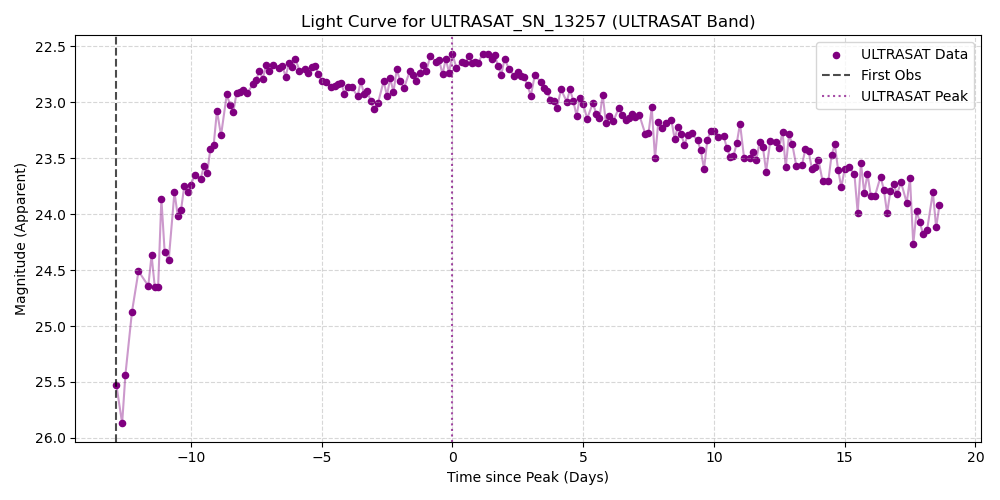

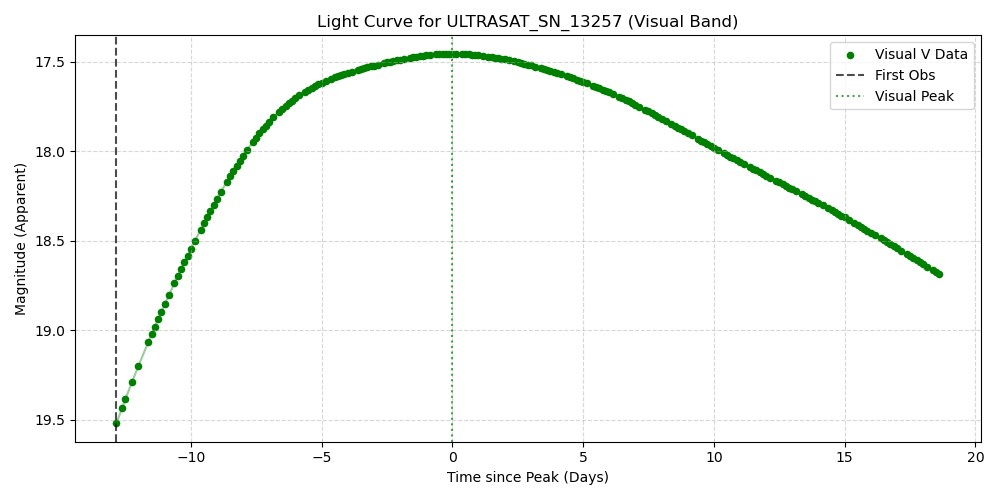

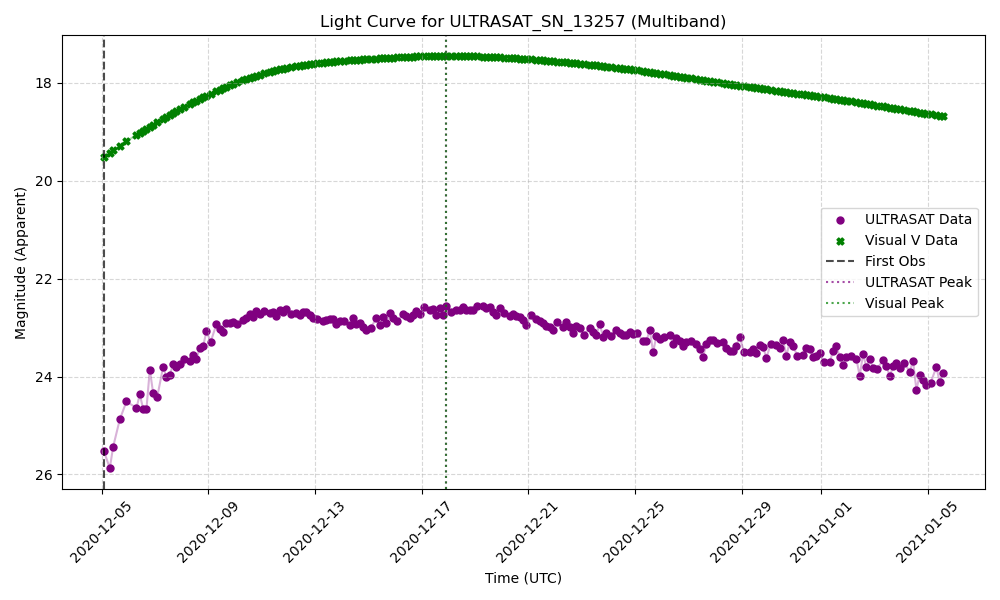

In [7]:
random_row_series = df_enriched.sample(n=1).iloc[0] 

# Try relative days for ULTRASAT
lc_plotter.plot_ultrasat_lc(random_row_series, time_format="relative_days")

# Try relative hours for Visual
lc_plotter.plot_visual_lc(random_row_series, time_format="relative_days")

# Try UTC for the multiband (relative should get blocked)
lc_plotter.plot_multiband_lc(random_row_series, time_format="UTC")

------------------------------------------
TEST B: Random Row (Pandas Series) Selection
------------------------------------------
Random Row chosen (representing Target: ULTRASAT_SN_209)
Plotting ULTRASAT (Relative Days)...


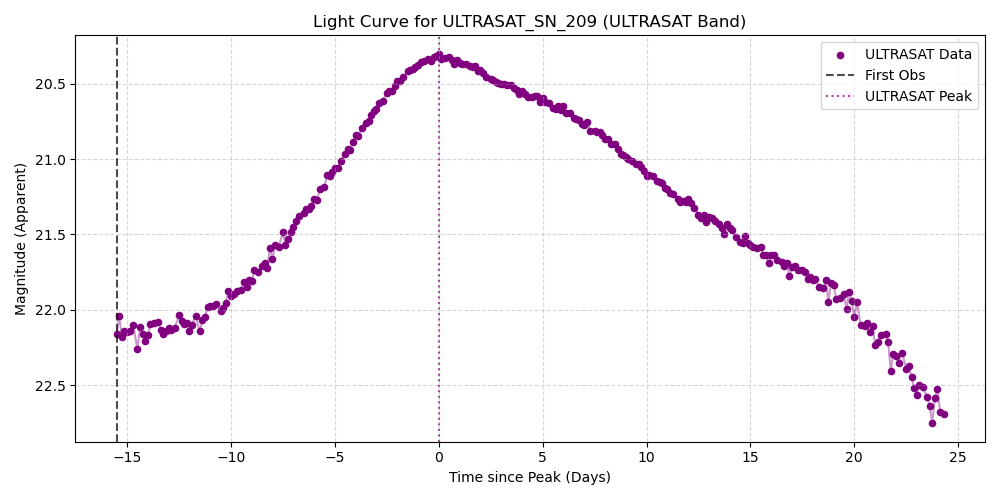

Plotting Visual (Relative Hours)...


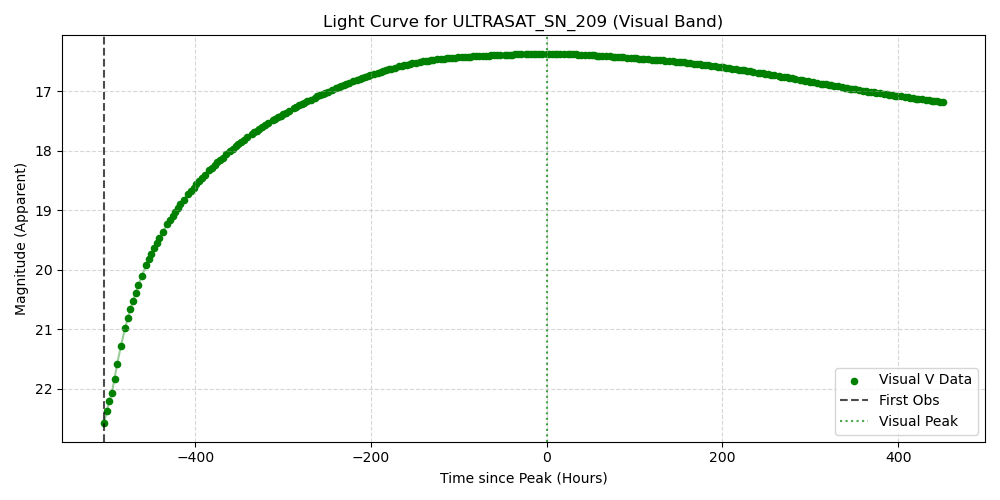

Plotting Multiband (UTC Calendar Dates)...


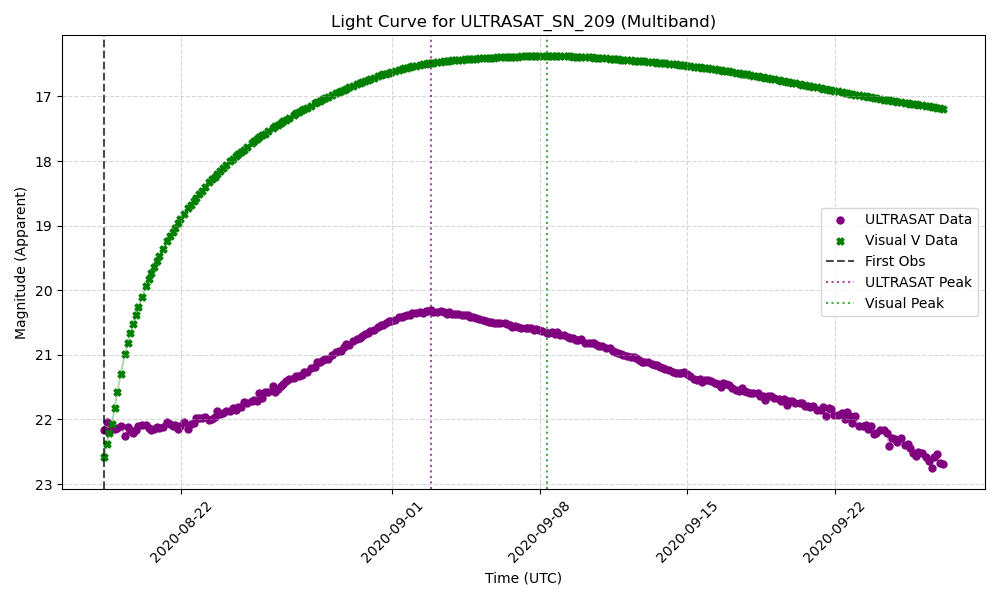

In [146]:
# ==========================================
# AVAILABLE PLOTTING OPTIONS (Cheat Sheet)
# ==========================================
#
# 1. Methods available:
#    - lc_plotter.plot_ultrasat_lc(target, time_format)
#    - lc_plotter.plot_visual_lc(target, time_format)
#    - lc_plotter.plot_multiband_lc(target, time_format)
#
# 2. 'time_format' string options:
#    - "MJD"            : Standard Modified Julian Date (Default)
#    - "UTC"            : Human-readable calendar dates
#    - "relative_days"  : T=0 is the peak; x-axis is in Days (Single band only)
#    - "relative_hours" : T=0 is the peak; x-axis is in Hours (Single band only)
#
# Note: If you pass a relative format to the multiband plot, 
# it will safely default to "MJD" to avoid conflicting peaks.
# ==========================================

# Test B: Select random row Series and test all 3 methods
print("------------------------------------------")
print("TEST B: Random Row (Pandas Series) Selection")
print("------------------------------------------")

# Select exactly one random row from the new ENRICHED dataframe
random_row_series = df_enriched.sample(n=1).iloc[0] 
print(f"Random Row chosen (representing Target: {random_row_series['Target_ID']})")

# Test 1: ULTRASAT band using Relative Days (T=0 is peak)
print("Plotting ULTRASAT (Relative Days)...")
lc_plotter.plot_ultrasat_lc(random_row_series, time_format="relative_days")

# Test 2: Visual band using Relative Hours (T=0 is peak)
print("Plotting Visual (Relative Hours)...")
lc_plotter.plot_visual_lc(random_row_series, time_format="relative_hours")

# Test 3: Multiband using UTC Calendar Dates
print("Plotting Multiband (UTC Calendar Dates)...")
lc_plotter.plot_multiband_lc(random_row_series, time_format="UTC")

In [93]:
# 1. Define the historical weather dictionaries (Month: % Clear)
mast_weather = {1: 0.52, 2: 0.56, 3: 0.55, 4: 0.51, 5: 0.77, 6: 0.89, 7: 0.92, 8: 0.90, 9: 0.76, 10: 0.67, 11: 0.60, 12: 0.64}
soxs_weather = {1: 0.85, 2: 0.88, 3: 0.86, 4: 0.82, 5: 0.78, 6: 0.75, 7: 0.75, 8: 0.79, 9: 0.84, 10: 0.86, 11: 0.88, 12: 0.85}
wilds_weather = {1: 0.67, 2: 0.70, 3: 0.77, 4: 0.84, 5: 0.93, 6: 0.90, 7: 0.45, 8: 0.50, 9: 0.80, 10: 0.87, 11: 0.76, 12: 0.66}

# 2. Instantiate the Observatories, passing the weather profiles in!

# MAST/DeepSpec
mast = Observatory.from_custom_location(
    name="MAST", lon_str="35d02m00s", lat_str="+30d03m00s", elevation_m=400, tz_str="Asia/Jerusalem",
    limiting_mag=19.5, min_obs_window=1.0, weather_profile=mast_weather
)

# NTT/SOXS
soxs = Observatory.from_custom_location(
    name="SOXS", lon_str="-70d44m00s", lat_str="-29d15m00s", elevation_m=2400, tz_str="America/Santiago",
    limiting_mag=19.5, min_obs_window=1.0, weather_profile=soxs_weather
)

# LDT/WILDS
wilds = Observatory.from_custom_location(
    name="WILDS", lon_str="-111d44m25s", lat_str="+34d44m40s", elevation_m=2360, tz_str="America/Phoenix",
    limiting_mag=19.5, min_obs_window=1.0, weather_profile=wilds_weather
)

print("✅ Telescopes loaded successfully with historical weather profiles!")

✅ Telescopes loaded successfully with historical weather profiles!


In [94]:
from core.dataprep_and_adjustment.Data_raw_adjustments import wrap_targets_and_times_for_astroplan

# 1. Run the new function on your enriched dataframe
df_astroplan_ready = wrap_targets_and_times_for_astroplan(df_enriched)

# 2. Let's prove it worked! Grab the very first observation time of the first row
test_time_object = df_astroplan_ready.loc[0, 'First_Observation_Time_MJD']

print("\n--- Object Verification ---")
print(f"What type of object is the time? {type(test_time_object)}")
print(f"Can we read its UTC format instantly? {test_time_object.iso}")

# 3. Save the living DataFrame to a Pickle file
save_path = "astroplan_ready_targets.pkl"
df_astroplan_ready.to_pickle(save_path)
print(f"\n✅ Data successfully preserved and saved to: {save_path}")

Upgrading DataFrame to Astroplan-ready objects...
Wrapping 284 time columns into Time objects (this might take a few seconds)...


c:\Users\golod\OneDrive\Desktop\steve\github\Observation-Strategy-simulations\core\dataprep_and_adjustment\Data_raw_adjustments.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_modified.insert(insert_loc, 'Astroplan_Target_Object', wrapped_objects)


✅ Super-table successfully built!

--- Object Verification ---
What type of object is the time? <class 'astropy.time.core.Time'>
Can we read its UTC format instantly? 2020-08-18 07:52:30.000

✅ Data successfully preserved and saved to: astroplan_ready_targets.pkl


In [95]:
import pandas as pd

# Load the frozen DataFrame back to life
df_loaded = pd.read_pickle("astroplan_ready_targets.pkl")

# Display the first 5 rows to inspect it
df_loaded.head()

,Target_ID,RA (deg),Dec (deg),Astroplan_Target_Object,Redshift,First_Observation_Time_MJD,Peak_Mag_ULTRASAT,Peak_Time_MJD_ULTRASAT,Peak_Mag_Visual,Peak_Time_MJD_Visual,Detection_Time_MJD_1,ULTRASAT_Magnitude_1,Visual_V_Magnitude_1,Detection_Time_MJD_2,ULTRASAT_Magnitude_2,Visual_V_Magnitude_2,Detection_Time_MJD_3,ULTRASAT_Magnitude_3,Visual_V_Magnitude_3,Detection_Time_MJD_4,ULTRASAT_Magnitude_4,Visual_V_Magnitude_4,Detection_Time_MJD_5,ULTRASAT_Magnitude_5,Visual_V_Magnitude_5,Detection_Time_MJD_6,ULTRASAT_Magnitude_6,Visual_V_Magnitude_6,Detection_Time_MJD_7,ULTRASAT_Magnitude_7,Visual_V_Magnitude_7,Detection_Time_MJD_8,ULTRASAT_Magnitude_8,Visual_V_Magnitude_8,Detection_Time_MJD_9,ULTRASAT_Magnitude_9,Visual_V_Magnitude_9,Detection_Time_MJD_10,ULTRASAT_Magnitude_10,Visual_V_Magnitude_10,Detection_Time_MJD_11,ULTRASAT_Magnitude_11,Visual_V_Magnitude_11,Detection_Time_MJD_12,ULTRASAT_Magnitude_12,Visual_V_Magnitude_12,Detection_Time_MJD_13,ULTRASAT_Magnitude_13,Visual_V_Magnitude_13,Detection_Time_MJD_14,ULTRASAT_Magnitude_14,Visual_V_Magnitude_14,Detection_Time_MJD_15,ULTRASAT_Magnitude_15,Visual_V_Magnitude_15,Detection_Time_MJD_16,ULTRASAT_Magnitude_16,Visual_V_Magnitude_16,Detection_Time_MJD_17,ULTRASAT_Magnitude_17,Visual_V_Magnitude_17,Detection_Time_MJD_18,ULTRASAT_Magnitude_18,Visual_V_Magnitude_18,Detection_Time_MJD_19,ULTRASAT_Magnitude_19,Visual_V_Magnitude_19,Detection_Time_MJD_20,ULTRASAT_Magnitude_20,Visual_V_Magnitude_20,Detection_Time_MJD_21,ULTRASAT_Magnitude_21,Visual_V_Magnitude_21,Detection_Time_MJD_22,ULTRASAT_Magnitude_22,Visual_V_Magnitude_22,Detection_Time_MJD_23,ULTRASAT_Magnitude_23,Visual_V_Magnitude_23,Detection_Time_MJD_24,ULTRASAT_Magnitude_24,Visual_V_Magnitude_24,Detection_Time_MJD_25,ULTRASAT_Magnitude_25,Visual_V_Magnitude_25,Detection_Time_MJD_26,ULTRASAT_Magnitude_26,Visual_V_Magnitude_26,Detection_Time_MJD_27,ULTRASAT_Magnitude_27,Visual_V_Magnitude_27,Detection_Time_MJD_28,ULTRASAT_Magnitude_28,Visual_V_Magnitude_28,Detection_Time_MJD_29,ULTRASAT_Magnitude_29,Visual_V_Magnitude_29,Detection_Time_MJD_30,ULTRASAT_Magnitude_30,Visual_V_Magnitude_30,Detection_Time_MJD_31,ULTRASAT_Magnitude_31,Visual_V_Magnitude_31,Detection_Time_MJD_32,ULTRASAT_Magnitude_32,Visual_V_Magnitude_32,Detection_Time_MJD_33,ULTRASAT_Magnitude_33,Visual_V_Magnitude_33,Detection_Time_MJD_34,ULTRASAT_Magnitude_34,Visual_V_Magnitude_34,Detection_Time_MJD_35,ULTRASAT_Magnitude_35,Visual_V_Magnitude_35,Detection_Time_MJD_36,ULTRASAT_Magnitude_36,Visual_V_Magnitude_36,Detection_Time_MJD_37,ULTRASAT_Magnitude_37,Visual_V_Magnitude_37,Detection_Time_MJD_38,ULTRASAT_Magnitude_38,Visual_V_Magnitude_38,Detection_Time_MJD_39,ULTRASAT_Magnitude_39,Visual_V_Magnitude_39,Detection_Time_MJD_40,ULTRASAT_Magnitude_40,Visual_V_Magnitude_40,Detection_Time_MJD_41,ULTRASAT_Magnitude_41,Visual_V_Magnitude_41,Detection_Time_MJD_42,ULTRASAT_Magnitude_42,Visual_V_Magnitude_42,Detection_Time_MJD_43,ULTRASAT_Magnitude_43,Visual_V_Magnitude_43,Detection_Time_MJD_44,ULTRASAT_Magnitude_44,Visual_V_Magnitude_44,Detection_Time_MJD_45,ULTRASAT_Magnitude_45,Visual_V_Magnitude_45,Detection_Time_MJD_46,ULTRASAT_Magnitude_46,Visual_V_Magnitude_46,Detection_Time_MJD_47,ULTRASAT_Magnitude_47,Visual_V_Magnitude_47,Detection_Time_MJD_48,ULTRASAT_Magnitude_48,Visual_V_Magnitude_48,Detection_Time_MJD_49,ULTRASAT_Magnitude_49,Visual_V_Magnitude_49,Detection_Time_MJD_50,ULTRASAT_Magnitude_50,Visual_V_Magnitude_50,Detection_Time_MJD_51,ULTRASAT_Magnitude_51,Visual_V_Magnitude_51,Detection_Time_MJD_52,ULTRASAT_Magnitude_52,Visual_V_Magnitude_52,Detection_Time_MJD_53,ULTRASAT_Magnitude_53,Visual_V_Magnitude_53,Detection_Time_MJD_54,ULTRASAT_Magnitude_54,Visual_V_Magnitude_54,Detection_Time_MJD_55,ULTRASAT_Magnitude_55,Visual_V_Magnitude_55,Detection_Time_MJD_56,ULTRASAT_Magnitude_56,Visual_V_Magnitude_56,Detection_Time_MJD_57,ULTRASAT_Magnitude_57,Visual_V_Magnitude_57,Detection_Time_MJD_58,ULTRASAT_Magnitude_58,Visual_V_Magnitude_58,Detection_Time_MJD_59,ULTRASAT_

In [12]:
import random
import pandas as pd

# 1. Grab a completely random row from your loaded Astroplan-ready table
random_idx = random.choice(df_loaded.index)
test_row = df_loaded.loc[random_idx]

# 2. Extract our two perfectly preserved Python objects!
target_wrapper = test_row['Astroplan_Target_Object']
peak_time_obj = test_row['Peak_Time_MJD_Visual']

target_name = target_wrapper.astroplan_target.name

# 3. Print the setup
print("==================================================")
print(f"🎯 VISIBILITY TEST: {target_name}")
print(f"⏰ Peak Time (MJD): {peak_time_obj.mjd:.2f}")
print(f"🗓️ Peak Time (UTC): {peak_time_obj.iso}")
print("==================================================")

# 4. Ask the observatories! (Using the new wrapper safety check we built)
mast_visible = mast.can_see(target_wrapper, peak_time_obj)
soxs_visible = soxs.can_see(target_wrapper, peak_time_obj)
wilds_visible = wilds.can_see(target_wrapper, peak_time_obj)

print(f"🔭 Visible from MAST (Israel)  : {mast_visible}")
print(f"🔭 Visible from SOXS (Chile)   : {soxs_visible}")
print(f"🔭 Visible from WILDS (USA)    : {wilds_visible}")
print("==================================================")

🎯 VISIBILITY TEST: ULTRASAT_SN_6808
⏰ Peak Time (MJD): 59116.25
🗓️ Peak Time (UTC): 2020-09-24 05:54:22.500
🔭 Visible from MAST (Israel)  : False
🔭 Visible from SOXS (Chile)   : True
🔭 Visible from WILDS (USA)    : False


In [26]:
import pandas as pd
import numpy as np
from astropy.time import Time

def build_global_unfiltered_schedule(df, mast_obs, soxs_obs, wilds_obs):
    print("Calculating GLOBAL absolute MJD windows (One continuous calculation per telescope)...")
    
    final_df = df.copy()
    
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
    
    mast_all, soxs_all, wilds_all = [], [], []
    
    for index, row in df.iterrows():
        target_wrapper = row['Astroplan_Target_Object']
        
        # --- NEW: Safely gather all valid Time objects for THIS specific row ---
        valid_times = []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            if isinstance(t_val, Time):
                valid_times.append(t_val)
        
        mast_win, soxs_win, wilds_win = [], [], []
        
        # Only calculate if we have at least a start and end time!
        if len(valid_times) >= 2:
            t_start = valid_times[0]  # The very first detection
            t_end = valid_times[-1]   # The very last valid detection for this row
            
            total_days = t_end.jd - t_start.jd
            
            if total_days > 0:
                def hrs_to_mjd(windows_hrs):
                    return [(round(t_start.mjd + (s / 24.0), 4), round(t_start.mjd + (e / 24.0), 4)) for s, e in windows_hrs]

                # Calculate all windows
                raw_mast = mast_obs.get_observation_windows(target_wrapper, t_start, window_days=total_days)
                mast_win = hrs_to_mjd(raw_mast)
                
                raw_soxs = soxs_obs.get_observation_windows(target_wrapper, t_start, window_days=total_days)
                soxs_win = hrs_to_mjd(raw_soxs)
                
                raw_wilds = wilds_obs.get_observation_windows(target_wrapper, t_start, window_days=total_days)
                wilds_win = hrs_to_mjd(raw_wilds)
        
        mast_all.append(mast_win)
        soxs_all.append(soxs_win)
        wilds_all.append(wilds_win)
        
    final_df['mast_all_windows_mjd'] = mast_all
    final_df['soxs_all_windows_mjd'] = soxs_all
    final_df['wilds_all_windows_mjd'] = wilds_all
    
    print("✅ Success! The global schedule table is built.")
    return final_df

In [112]:
# 1. Grab 3 rows to test
df_test_sample = df_loaded

# 2. Run the new global calculation
df_global_windows = build_global_unfiltered_schedule(df_test_sample, mast, soxs, wilds)

# 3. Look at ONLY the new columns to verify they filled up
cols_to_view = ['Target_ID', 'mast_all_windows_mjd', 'soxs_all_windows_mjd', 'wilds_all_windows_mjd']
display(df_global_windows[cols_to_view])

Calculating GLOBAL absolute MJD windows (One continuous calculation per telescope)...
✅ Success! The global schedule table is built.


,Target_ID,mast_all_windows_mjd,soxs_all_windows_mjd,wilds_all_windows_mjd
0,ULTRASAT_SN_209,[],"[(59079.3281, 59079.401), (59080.2344, 59080.401), (59081.2344, 59081.401), (59082.2344, 59082.401), (59083.224, 59083.401), (59084.224, 59084.401), (59085.224, 59085.401), (59086.224, 59086.401), (59087.2135, 59087.401), (59088.2135, 59088.401), (59089.2135, 59089.401), (59090.2135, 59090.401), (59091.2031, 59091.401), (59092.2031, 59092.401), (59093.2031, 59093.401), (59094.1927, 59094.3906), (59095.1927, 59095.3906), (59096.1927, 59096.3906), (59097.1927, 59097.3906), (59098.1823, 59098.3906), (59099.1823, 59099.3906), (59100.1823, 59100.3906), (59101.1823, 59101.3906), (59102.1719, 59102.3906), (59103.1719, 59103.3906), (59104.1719, 59104.3906), (59105.1719, 59105.3906), (59106.1615, 59106.3906), (59107.1615, 59107.3802), (59108.1615, 59108.3802), (59109.1615, 59109.3802), (59110.151, 59110.3802), (59111.151, 59111.3802), (59112.151, 59112.3802), (59113.1406, 59113.3802), (59114.1406, 59114.3802), (59115.1406, 59115.3802), (59116.1406, 59116.3802), (59117.1302, 59117.3802), (59118.1302, 59118.3802)]",[]
1,ULTRASAT_SN_236,[],"[(59163.3281, 59163.3385), (59164.0365, 59164.3385), (59165.0365, 59165.3385), (59166.0365, 59166.3385), (59167.0365, 59167.3385), (59168.0365, 59168.3385), (59169.0365, 59169.3385), (59170.0365, 59170.3385), (59171.0365, 59171.3385), (59172.0365, 59172.3385), (59173.0365, 59173.3281), (59174.0365, 59174.3281), (59175.0365, 59175.3281), (59176.0469, 59176.3281), (59177.0469, 59177.3281), (59178.0469, 59178.3281), (59179.0469, 59179.3281), (59180.0469, 59180.3281), (59181.0469, 59181.3281), (59182.0469, 59182.3281)]",[]
2,ULTRASAT_SN_279,[],"[(59012.4206, 59012.4206), (59013.4206, 59013.4206), (59014.4206, 59014.4206), (59015.4102, 59015.4206), (59016.4102, 59016.4206), (59017.4102, 59017.4206), (59018.4102, 59018.4206), (59019.3997, 59019.4206), (59020.3997, 59020.4206), (59021.3997, 59021.4206), (59022.3997, 59022.4206), (59023.3893, 59023.4206), (59024.3893, 59024.4206), (59025.3893, 59025.4206), (59026.3893, 59026.4206), (59027.3789, 59027.4206), (59028.3789, 59028.4206), (59029.3789, 59029.4206), (59030.3789, 59030.4206), (59031.3685, 59031.4206), (59032.3685, 59032.4206), (59033.3685, 59033.4206), (59034.3581, 59034.4206), (59035.3581, 59035.4206), (59036.3581, 59036.4206), (59037.3581, 59037.4206), (59038.3477, 59038.4206), (59039.3477, 59039.4206), (59040.3477, 59040.4206), (59041.3477, 59041.4206), (59042.3372, 59042.4206), (59043.3372, 59043.4206), (59044.3372, 59044.4206), (59045.3372, 59045.4206)]",[]
3,ULTRASAT_SN_404,"[(59245.0052, 59245.1302), (59246.0052, 59246.1302), (59246.9948, 59247.1302), (59247.9948, 59248.1198), (59248.9948, 59249.1198), (59249.9948, 59250.1198), (59250.9844, 59251.1198), (59251.9844, 59252.1198), (59252.9844, 59253.1198), (59253.9844, 59254.1198), (59254.974, 59255.1198), (59255.974, 59256.1198), (59256.974, 59257.1198), (59257.9635, 59258.1198), (59258.9635, 59259.1198), (59259.9635, 59260.1198), (59260.9635, 59261.1198), (59261.9531, 59262.1198), (59262.9531, 59263.1198), (59263.9531, 59264.1198), (59264.9531, 59265.1198), (59265.9427, 59266.1198), (59266.9427, 59267.1198), (59267.9427, 59268.1094), (59268.9427, 59269.1094), (59269.9323, 59270.1094), (59270.9323, 59271.1094), (59271.9323, 59272.1094), (59272.9323, 59273.1094), (59273.9219, 59274.1094), (59274.9219, 59275.1094), (59275.9219, 59276.1094), (59276.9115, 59277.1094), (59277.9115, 59278.1094), (59278.9115, 59279.1094), (59279.9115, 59280.1094), (59280.901, 59281.1094), (59281.901, 59282.099), (59282.901, 59283.099), (59283.901, 59284.026)]",[],"[(59244.3906, 59244.5365), (59245.3802, 59245.5365), (59246.3802, 59246.5365), (59247.3802, 59247.5365), (59248.3802, 59248.5365), (59249.3698, 59249.5365), (59250.3698, 59250.5365), (59251.3698, 59251.5365), (59252.3698, 59252.5365), (59253.3594, 59253.5365), (59254.3594, 59254.5365), (59255.3594, 59255.526), (59256.349, 59256.526), (59257.349, 59257.526), (59258.

In [24]:
# 1. Tell Pandas to show ALL columns, no matter how many there are
pd.set_option('display.max_columns', None)

# 2. Tell Pandas to show the full width of the cell (so your lists of times don't get cut off)
pd.set_option('display.max_colwidth', None)

# 3. Display the 3-row test table again
display(df_unfiltered_windows)

Target_ID    RA (deg)  Dec (deg)  \
0   ULTRASAT_SN_209   55.355652 -44.200012   
1   ULTRASAT_SN_236   66.717491 -48.844906   
2   ULTRASAT_SN_279   58.279404 -51.718433   
3   ULTRASAT_SN_404  247.454636  64.174316   
4   ULTRASAT_SN_428  248.524490  58.392799   
5   ULTRASAT_SN_687  243.259811  62.279285   
6   ULTRASAT_SN_702  250.601334  55.058067   
7   ULTRASAT_SN_807   62.366520 -41.729641   
8   ULTRASAT_SN_832  244.912750  54.720440   
9  ULTRASAT_SN_1036   55.939384 -44.689728   

                                                                                    Astroplan_Target_Object  \
0  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025E9E11EBD0>   
1  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025E9E0E1730>   
2  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA1183380>   
3  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA119D820>   
4  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA11B3C80>   
5  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA11CE120>   
6  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA11E85C0>   
7  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA1202A20>   
8  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA1220EC0>   
9  <core.dataprep_and_adjustment.Data_raw_adjustments.Target_ULTRASAT_Wrapped object at 0x0000025EA1237320>   

   Redshift First_Observation_Time_MJD  Peak_Mag_ULTRASAT  \
0   0.03115               59079.328125          20.300903   
1   0.03465               59163.328125          22.153499   
2   0.03465             59012.31640625          21.401580   
3   0.04125               59244.265625          21.329039   
4   0.03235             59197.41015625          20.483545   
5   0.03185               59278.421875          21.286474   
6   0.04015             59221.75390625          23.461457   
7   0.04505             59096.01953125          22.127491   
8   0.02275             59204.01953125          20.459210   
9   0.04045             59046.87890625          23.558136   

  Peak_Time_MJD_ULTRASAT  Peak_Mag_Visual Peak_Time_MJD_Visual  \
0           59094.828125        16.373412         59100.328125   
1           59170.578125        17.189168            59177.125   
2         59021.10546875        17.037800       59027.10546875   
3           59260.265625        17.093229       59265.03515625   
4         59212.91015625        16.526892       59218.41015625   
5           59292.921875        16.749990         59299.546875   
6         59235.87890625        17.735928       59242.75390625   
7           59112.515625        17.418834         59116.890625   
8         59219.24609375        16.123183       59225.01953125   
9         59061.01171875        17.820366       59067.75390625   

  Detection_Time_MJD_1  ULTRASAT_Magnitude_1  Visual_V_Magnitude_1  \
0         59079.328125             22.158336             22.579282   
1         59163.328125             25.033057             19.341777   
2       59012.31640625             25.660671             19.419499   
3         59244.265625             23.072280             22.859981   
4       59197.41015625             22.518295             22.790723   
5         59278.421875             25.502986             23.788191   
6       59221.75390625             25.676590             24.228669   
7       59096.01953125             23.969331             23.300137   
8       59204.01953125             22.760976             22.580774   
9       59046.87890625             25.390648             24.139399   

           mast_windows_mjd_1          soxs_windows_mjd_1  \
0                          []   [(59079.3281, 5907

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.time import Time

def plot_filtered_lightcurve(row, time_format="relative_hours", mag_limit=19.5, min_hours=1.0):
    """
    Plots the light curve and color-codes the windows:
    GREEN = Good (>= 1 hour AND Magnitude <= 19.5)
    RED = Bad (Too short OR Too faint)
    """
    target_name = row['Target_ID']
    
    # --- GET THE ZERO POINT (T=0) ---
    peak_obj = row.get('Peak_Time_MJD_Visual')
    peak_mjd = peak_obj.mjd if isinstance(peak_obj, Time) else peak_obj

    def convert_time(raw_mjd):
        if time_format == "relative_hours": return (raw_mjd - peak_mjd) * 24.0
        elif time_format == "relative_days": return (raw_mjd - peak_mjd)
        else: return raw_mjd 

    # 1. Extract Light Curve Data (We need raw MJD for interpolation later!)
    raw_mjd_times = []
    u_mags = []
    v_mags = []
    plot_times = []
    
    det_cols = [c for c in row.index if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
            
    for i in range(1, max_idx + 1):
        t_val = row.get(f"Detection_Time_MJD_{i}")
        u_val = row.get(f"ULTRASAT_Magnitude_{i}")
        v_val = row.get(f"Visual_V_Magnitude_{i}")
        
        if isinstance(t_val, Time): t_val = t_val.mjd
            
        if pd.notna(t_val) and pd.notna(u_val) and pd.notna(v_val):
            raw_mjd_times.append(t_val)
            plot_times.append(convert_time(t_val))
            u_mags.append(u_val)
            v_mags.append(v_val)
            
    # 2. The Filter Engine (Evaluates if a window is Red or Green)
    def evaluate_windows(windows):
        good_blocks, bad_blocks = [], []
        if not isinstance(windows, list): return good_blocks, bad_blocks
        
        for start_mjd, end_mjd in windows:
            # Check 1: Time Filter
            duration_hours = (end_mjd - start_mjd) * 24.0
            
            # Check 2: Magnitude Filter (Interpolate the V-mag at the START of the window)
            # Since numpy interp requires sorted x-values, we ensure our times are sorted
            sorted_indices = np.argsort(raw_mjd_times)
            sorted_times = np.array(raw_mjd_times)[sorted_indices]
            sorted_mags = np.array(v_mags)[sorted_indices]
            
            estimated_mag = np.interp(start_mjd, sorted_times, sorted_mags)
            
            # Convert for the plot
            start_scaled = convert_time(start_mjd)
            width_scaled = convert_time(end_mjd) - start_scaled
            
            # The Final Verdict
            if duration_hours >= min_hours and estimated_mag <= mag_limit:
                good_blocks.append((start_scaled, width_scaled))
            else:
                bad_blocks.append((start_scaled, width_scaled))
                
        return good_blocks, bad_blocks
        
    mast_good, mast_bad = evaluate_windows(row.get("mast_all_windows_mjd", []))
    soxs_good, soxs_bad = evaluate_windows(row.get("soxs_all_windows_mjd", []))
    wilds_good, wilds_bad = evaluate_windows(row.get("wilds_all_windows_mjd", []))

    # ==========================================
    # 3. BUILD THE PLOT
    # ==========================================
    fig, (ax_lc, ax_gantt) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                                          gridspec_kw={'height_ratios': [3, 1]})
    
    fig.suptitle(f"Observation Schedule: {target_name} (Green=Valid, Red=Invalid)", fontsize=16, fontweight='bold')
    
    # --- TOP PLOT: Light Curve ---
    ax_lc.plot(plot_times, u_mags, 'o-', color='purple', label="ULTRASAT (UV)", linewidth=2, markersize=6)
    ax_lc.plot(plot_times, v_mags, 's-', color='gray', label="Visual (V)", linewidth=2, markersize=6)
    
    # Draw a dashed line to show the 19.5 magnitude limit!
    ax_lc.axhline(y=mag_limit, color='red', linestyle=':', linewidth=2, label=f"Limit ({mag_limit} mag)")
    
    ax_lc.invert_yaxis() 
    ax_lc.set_ylabel("Apparent Magnitude", fontsize=12)
    ax_lc.grid(True, linestyle='--', alpha=0.6)
    ax_lc.legend(loc="upper right")
    
    if time_format in ["relative_hours", "relative_days"]:
        ax_lc.axvline(x=0, color='grey', linestyle='-', linewidth=2, alpha=0.5)
        ax_gantt.axvline(x=0, color='grey', linestyle='-', linewidth=2, alpha=0.5)
    
    # --- BOTTOM PLOT: Telescope Windows (Red/Green logic) ---
    y_wilds, y_soxs, y_mast = 25, 15, 5
    thickness = 8
    
    # Plot Bad (Red)
    if wilds_bad: ax_gantt.broken_barh(wilds_bad, (y_wilds, thickness), facecolors='red', edgecolor='black', alpha=0.6)
    if soxs_bad: ax_gantt.broken_barh(soxs_bad, (y_soxs, thickness), facecolors='red', edgecolor='black', alpha=0.6)
    if mast_bad: ax_gantt.broken_barh(mast_bad, (y_mast, thickness), facecolors='red', edgecolor='black', alpha=0.6)
        
    # Plot Good (Green) overlaid so they pop out
    if wilds_good: ax_gantt.broken_barh(wilds_good, (y_wilds, thickness), facecolors='lime', edgecolor='black', alpha=0.9)
    if soxs_good: ax_gantt.broken_barh(soxs_good, (y_soxs, thickness), facecolors='lime', edgecolor='black', alpha=0.9)
    if mast_good: ax_gantt.broken_barh(mast_good, (y_mast, thickness), facecolors='lime', edgecolor='black', alpha=0.9)
        
    ax_gantt.set_ylim(0, 40)
    ax_gantt.set_yticks([9, 19, 29])
    ax_gantt.set_yticklabels(['MAST (Israel)', 'SOXS (Chile)', 'WILDS (USA)'])
    
    if time_format == "relative_hours": ax_gantt.set_xlabel("Hours Relative to Visual Peak (T=0)", fontsize=12)
    elif time_format == "relative_days": ax_gantt.set_xlabel("Days Relative to Visual Peak (T=0)", fontsize=12)
    else: ax_gantt.set_xlabel("Time (MJD)", fontsize=12)
        
    ax_gantt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [98]:
# Grab a random row to visualize
random_row = df_global_windows.sample(n=1).iloc[0]

# Generate the diagnostic chart
plot_diagnostic_lightcurve(random_row, time_format="relative_hours")

TypeError: plot_diagnostic_lightcurve() missing 3 required positional arguments: 'mast_weather', 'soxs_weather', and 'wilds_weather'

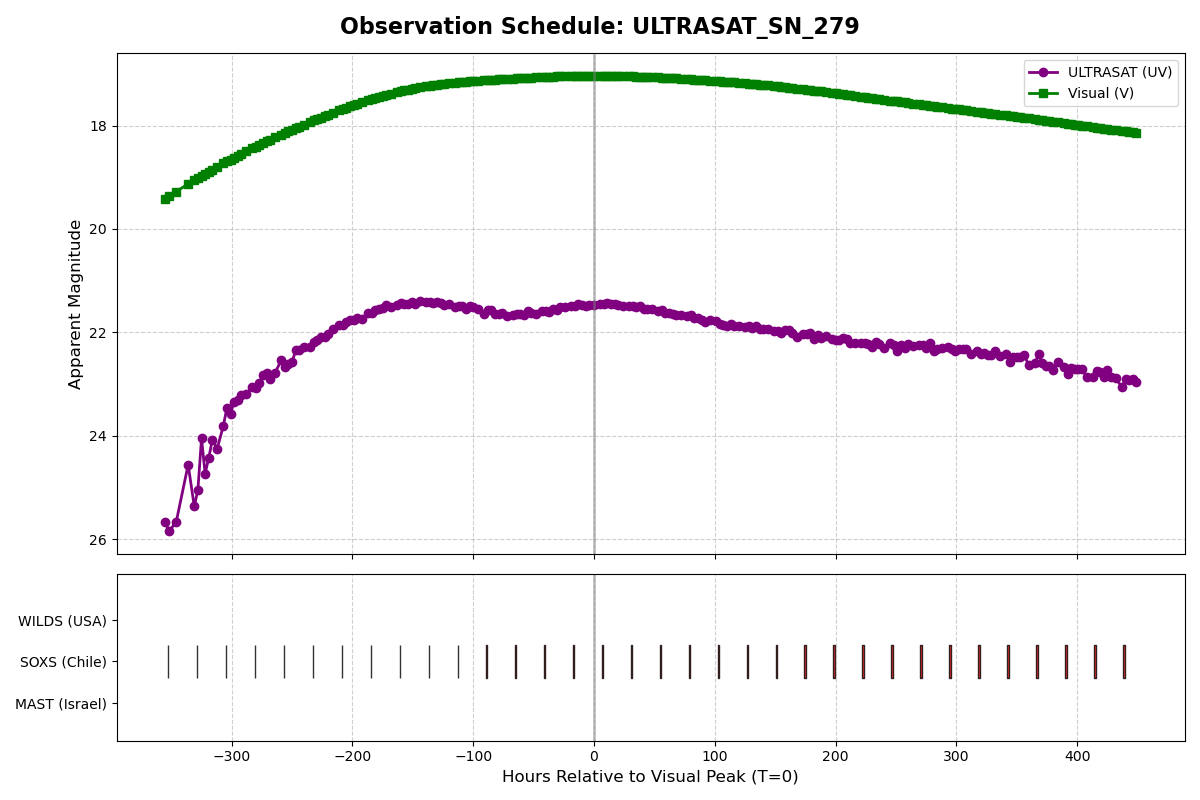

In [97]:
# Generate the interactive chart
plot_lightcurve_with_windows(random_row, time_format="relative_hours")

In [99]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import random
from astropy.time import Time

def plot_diagnostic_lightcurve(row, mast_weather, soxs_weather, wilds_weather, time_format="relative_hours", mag_limit=19.5, min_hours=1.0):
    """
    Plots the light curve and color-codes the windows by failure reason:
    GREEN = Good
    BROWN = Clouded Out (Weather Monte Carlo Failed)
    ORANGE = Too short (< 1 hour)
    RED = Too faint (> 19.5 mag)
    GRAY = Failed both (Short and Faint)
    """
    target_name = row['Target_ID']
    
    # --- GET THE ZERO POINT (T=0) ---
    peak_obj = row.get('Peak_Time_MJD_Visual')
    peak_mjd = peak_obj.mjd if isinstance(peak_obj, Time) else peak_obj

    def convert_time(raw_mjd):
        if time_format == "relative_hours": return (raw_mjd - peak_mjd) * 24.0
        elif time_format == "relative_days": return (raw_mjd - peak_mjd)
        else: return raw_mjd 

    # 1. Extract Light Curve Data
    raw_mjd_times = []
    u_mags = []
    v_mags = []
    plot_times = []
    
    det_cols = [c for c in row.index if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
            
    for i in range(1, max_idx + 1):
        t_val = row.get(f"Detection_Time_MJD_{i}")
        u_val = row.get(f"ULTRASAT_Magnitude_{i}")
        v_val = row.get(f"Visual_V_Magnitude_{i}")
        
        if isinstance(t_val, Time): t_val = t_val.mjd
            
        if pd.notna(t_val) and pd.notna(u_val) and pd.notna(v_val):
            raw_mjd_times.append(t_val)
            plot_times.append(convert_time(t_val))
            u_mags.append(u_val)
            v_mags.append(v_val)
            
    # 2. The Advanced Diagnostic Filter Engine WITH WEATHER
    def evaluate_windows(windows, weather_dict):
        good, short, faint, both, clouded = [], [], [], [], []
        if not isinstance(windows, list): return good, short, faint, both, clouded
        
        for start_mjd, end_mjd in windows:
            start_scaled = convert_time(start_mjd)
            width_scaled = convert_time(end_mjd) - start_scaled
            
            # --- WEATHER MONTE CARLO ROLL ---
            window_time = Time(start_mjd, format='mjd')
            month = window_time.datetime.month
            clear_prob = weather_dict.get(month, 1.0)
            
            # Roll the dice! If random number is higher than clear_prob, it rains.
            if random.random() > clear_prob:
                clouded.append((start_scaled, width_scaled))
                continue # Skip all other checks, the telescope is closed!
                
            # --- TIME & MAGNITUDE CHECKS ---
            duration_hours = (end_mjd - start_mjd) * 24.0
            
            sorted_indices = np.argsort(raw_mjd_times)
            sorted_times = np.array(raw_mjd_times)[sorted_indices]
            sorted_mags = np.array(v_mags)[sorted_indices]
            estimated_mag = np.interp(start_mjd, sorted_times, sorted_mags)
            
            is_long = duration_hours >= min_hours
            is_bright = estimated_mag <= mag_limit
            
            if is_long and is_bright:
                good.append((start_scaled, width_scaled))
            elif not is_long and is_bright:
                short.append((start_scaled, width_scaled))
            elif is_long and not is_bright:
                faint.append((start_scaled, width_scaled))
            else:
                both.append((start_scaled, width_scaled))
                
        return good, short, faint, both, clouded
        
    # Evaluate with the specific weather profiles
    m_good, m_short, m_faint, m_both, m_clouded = evaluate_windows(row.get("mast_all_windows_mjd", []), mast_weather)
    s_good, s_short, s_faint, s_both, s_clouded = evaluate_windows(row.get("soxs_all_windows_mjd", []), soxs_weather)
    w_good, w_short, w_faint, w_both, w_clouded = evaluate_windows(row.get("wilds_all_windows_mjd", []), wilds_weather)

    # ==========================================
    # 3. BUILD THE PLOT
    # ==========================================
    fig, (ax_lc, ax_gantt) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, 
                                          gridspec_kw={'height_ratios': [3, 1.2]})
    
    fig.suptitle(f"Diagnostic Observation Schedule: {target_name}", fontsize=16, fontweight='bold')
    
    # --- TOP PLOT: Light Curve ---
    ax_lc.plot(plot_times, u_mags, 'o-', color='purple', label="ULTRASAT (UV)", linewidth=2, markersize=6)
    ax_lc.plot(plot_times, v_mags, 's-', color='gray', label="Visual (V)", linewidth=2, markersize=6)
    
    ax_lc.axhline(y=mag_limit, color='red', linestyle=':', linewidth=2, label=f"Limit ({mag_limit} mag)")
    ax_lc.invert_yaxis() 
    ax_lc.set_ylabel("Apparent Magnitude", fontsize=12)
    ax_lc.grid(True, linestyle='--', alpha=0.6)
    ax_lc.legend(loc="upper right")
    
    # --- ADD THE CALENDAR MONTH BAR TO THE TOP ---
    ax_month = ax_lc.twiny()
    ax_month.set_xlim(ax_lc.get_xlim())
    
    # Generate ticks based on the bottom x-axis, convert to calendar months
    def update_month_axis(ax_bottom, ax_top):
        ticks = ax_bottom.get_xticks()
        valid_ticks, labels = [], []
        for tick in ticks:
            # Reverse engineer the relative time back to MJD
            if time_format == "relative_hours": mjd = peak_mjd + (tick / 24.0)
            elif time_format == "relative_days": mjd = peak_mjd + tick
            else: mjd = tick
            
            # Make sure the MJD is valid before converting
            if 40000 < mjd < 70000:
                valid_ticks.append(tick)
                # Format as 'Month Year' (e.g., 'Aug 2026')
                labels.append(Time(mjd, format='mjd').datetime.strftime('%b %Y'))
                
        ax_top.set_xticks(valid_ticks)
        ax_top.set_xticklabels(labels, fontsize=10, rotation=0)
        ax_top.set_xlabel("Calendar Month", fontsize=12, labelpad=10)

    # Force drawing so the ticks populate, then update the top axis
    fig.canvas.draw()
    update_month_axis(ax_gantt, ax_month)
    
    if time_format in ["relative_hours", "relative_days"]:
        ax_lc.axvline(x=0, color='grey', linestyle='-', linewidth=2, alpha=0.5)
        ax_gantt.axvline(x=0, color='grey', linestyle='-', linewidth=2, alpha=0.5)
    
    # --- BOTTOM PLOT: Telescope Windows ---
    y_wilds, y_soxs, y_mast = 25, 15, 5
    thickness = 8
    
    def draw_blocks(ax, blocks, y_pos, color, alpha=0.8):
        if blocks: ax.broken_barh(blocks, (y_pos, thickness), facecolors=color, edgecolor='black', alpha=alpha)

    # Draw Failed Both (Gray)
    draw_blocks(ax_gantt, w_both, y_wilds, 'gray', 0.5)
    draw_blocks(ax_gantt, s_both, y_soxs, 'gray', 0.5)
    draw_blocks(ax_gantt, m_both, y_mast, 'gray', 0.5)
    
    # Draw Too Faint (Red)
    draw_blocks(ax_gantt, w_faint, y_wilds, 'red', 0.7)
    draw_blocks(ax_gantt, s_faint, y_soxs, 'red', 0.7)
    draw_blocks(ax_gantt, m_faint, y_mast, 'red', 0.7)
    
    # Draw Too Short (Orange)
    draw_blocks(ax_gantt, w_short, y_wilds, 'orange', 0.8)
    draw_blocks(ax_gantt, s_short, y_soxs, 'orange', 0.8)
    draw_blocks(ax_gantt, m_short, y_mast, 'orange', 0.8)

    # Draw Clouded Out (Brown)
    draw_blocks(ax_gantt, w_clouded, y_wilds, 'saddlebrown', 0.85)
    draw_blocks(ax_gantt, s_clouded, y_soxs, 'saddlebrown', 0.85)
    draw_blocks(ax_gantt, m_clouded, y_mast, 'saddlebrown', 0.85)

    # Draw Good (Lime Green) overlaid on top
    draw_blocks(ax_gantt, w_good, y_wilds, 'lime', 1.0)
    draw_blocks(ax_gantt, s_good, y_soxs, 'lime', 1.0)
    draw_blocks(ax_gantt, m_good, y_mast, 'lime', 1.0)
        
    ax_gantt.set_ylim(0, 45) 
    ax_gantt.set_yticks([9, 19, 29])
    ax_gantt.set_yticklabels(['MAST (Israel)', 'SOXS (Chile)', 'WILDS (USA)'])
    
    if time_format == "relative_hours": ax_gantt.set_xlabel("Hours Relative to Visual Peak (T=0)", fontsize=12)
    elif time_format == "relative_days": ax_gantt.set_xlabel("Days Relative to Visual Peak (T=0)", fontsize=12)
    else: ax_gantt.set_xlabel("Time (MJD)", fontsize=12)
        
    ax_gantt.grid(True, axis='x', linestyle='--', alpha=0.6)
    
    # --- GANTT CUSTOM LEGEND ---
    patch_good = mpatches.Patch(color='lime', label='Valid Window')
    patch_cloud = mpatches.Patch(color='saddlebrown', label='Clouded Out')
    patch_short = mpatches.Patch(color='orange', label='Failed: < 1 Hour')
    patch_faint = mpatches.Patch(color='red', label=f'Failed: > {mag_limit} Mag')
    patch_both = mpatches.Patch(color='gray', label='Failed: Both')
    
    ax_gantt.legend(handles=[patch_good, patch_cloud, patch_short, patch_faint, patch_both], 
                    loc='upper right', ncol=5, fontsize=9)
    
    plt.tight_layout()
    plt.show()

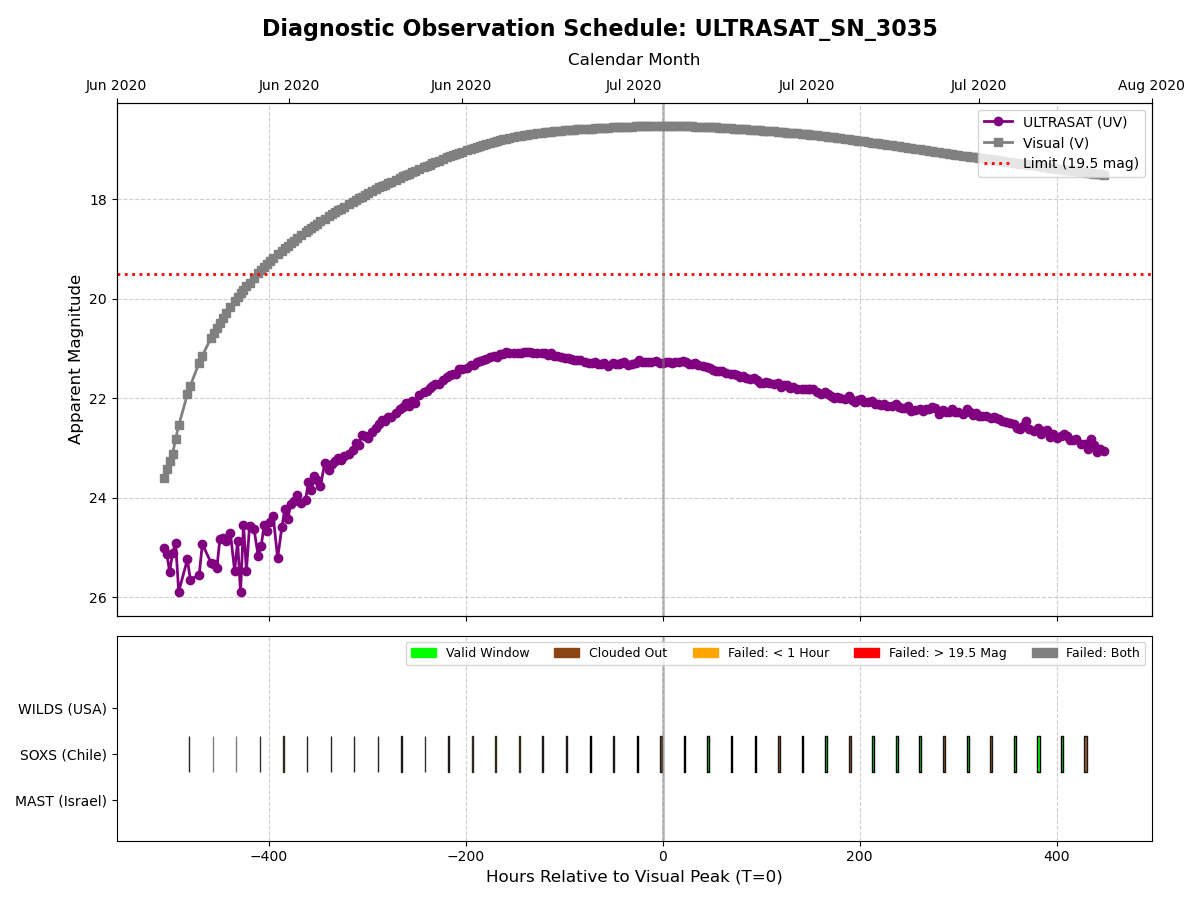

In [103]:
# Grab a random row to visualize
random_row = df_global_windows.sample(n=1).iloc[0]

# Generate the diagnostic chart with weather!
plot_diagnostic_lightcurve(random_row, mast.weather_profile, soxs.weather_profile, wilds.weather_profile, time_format="relative_hours")

In [114]:
import plotly.express as px
import pandas as pd
import numpy as np
import random
from astropy.time import Time
from datetime import timedelta

def plot_mission_timeline(df, telescope_name, window_column, weather_dict, mag_limit=19.5, min_hours=1.0):
    print(f"Flattening schedule and calculating physics/weather for {telescope_name}...")
    
    all_blocks = []
    global_min_mjd = np.inf
    global_max_mjd = -np.inf
    
    color_map = {
        'Valid Window': '#00FF00',        # Lime Green
        'Clouded Out': '#8B4513',         # Saddlebrown
        'Too Short (< 1h)': '#FFA500',    # Orange
        'Too Faint (> 19.5)': '#FF0000',  # Red
        'Failed Both': '#808080'          # Gray
    }

    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])

    for index, row in df.iterrows():
        target_name = row['Target_ID']
        
        # --- NEW: Grabs the exact column you ask for (MAST, SOXS, or WILDS) ---
        windows = row.get(window_column, [])
        
        raw_mjd_times, v_mags = [], []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            v_val = row.get(f"Visual_V_Magnitude_{i}")
            
            if isinstance(t_val, Time): t_val = t_val.mjd
                
            if pd.notna(t_val) and pd.notna(v_val):
                raw_mjd_times.append(t_val)
                v_mags.append(v_val)
                
                if t_val < global_min_mjd: global_min_mjd = t_val
                if t_val > global_max_mjd: global_max_mjd = t_val
                
        if len(raw_mjd_times) == 0: continue
        if not isinstance(windows, list) or len(windows) == 0: continue
            
        sorted_indices = np.argsort(raw_mjd_times)
        sorted_times = np.array(raw_mjd_times)[sorted_indices]
        sorted_mags = np.array(v_mags)[sorted_indices]

        for start_mjd, end_mjd in windows:
            duration_hours = (end_mjd - start_mjd) * 24.0
            
            window_time = Time(start_mjd, format='mjd')
            month = window_time.datetime.month
            clear_prob = weather_dict.get(month, 1.0)
            
            estimated_mag = np.interp(start_mjd, sorted_times, sorted_mags)
            is_long = duration_hours >= min_hours
            is_bright = estimated_mag <= mag_limit
            
            if random.random() > clear_prob:
                status = 'Clouded Out'
            elif is_long and is_bright: status = 'Valid Window'
            elif not is_long and is_bright: status = 'Too Short (< 1h)'
            elif is_long and not is_bright: status = 'Too Faint (> 19.5)'
            else: status = 'Failed Both'

            start_dt = Time(start_mjd, format='mjd').datetime
            end_dt = Time(end_mjd, format='mjd').datetime
            
            all_blocks.append({
                'Target': target_name,
                'Start': start_dt,
                'End': end_dt,
                'Status': status,
                'Duration (Hours)': round(duration_hours, 2),
                'Est. Magnitude': round(estimated_mag, 2)
            })

    df_plot = pd.DataFrame(all_blocks)
    
    if df_plot.empty:
        print(f"No windows found to plot for {telescope_name}!")
        return
        
    unique_targets = df_plot['Target'].nunique()
    dynamic_height = max(400, (unique_targets * 25) + 150)
    
    start_bound_dt = Time(global_min_mjd, format='mjd').datetime
    end_bound_dt = Time(global_max_mjd, format='mjd').datetime
        
    print(f"Building Dashboard for {unique_targets} targets out of the {len(df)} total targets...")
    fig = px.timeline(
        df_plot, 
        x_start="Start", 
        x_end="End", 
        y="Target", 
        color="Status",
        color_discrete_map=color_map,
        hover_data=['Duration (Hours)', 'Est. Magnitude'],
        # --- NEW: Dynamic Title ---
        title=f"{telescope_name} Mission Observation Schedule (Interactive)"
    )
    
    fig.update_yaxes(autorange="reversed") 
    fig.update_traces(marker_line_width=0, opacity=1.0)
    
    fig.update_layout(
        xaxis_title="Calendar Date",
        yaxis_title="Supernova Target ID",
        xaxis=dict(range=[start_bound_dt, end_bound_dt]),
        height=dynamic_height, 
        showlegend=True,
        legend_title="Window Status (Click to Toggle)"
    )
    
    fig.show()

In [115]:
plot_mission_timeline(df_global_windows, "SOXS", "soxs_all_windows_mjd", soxs.weather_profile)

Flattening schedule and calculating physics/weather for SOXS...
Building Dashboard for 62 targets out of the 117 total targets...


In [117]:
plot_mission_timeline(df_global_windows, "MAST", "mast_all_windows_mjd", soxs.weather_profile)

Flattening schedule and calculating physics/weather for MAST...
Building Dashboard for 49 targets out of the 117 total targets...


In [118]:
plot_mission_timeline(df_global_windows, "WILDS", "wilds_all_windows_mjd", wilds.weather_profile)

Flattening schedule and calculating physics/weather for WILDS...
Building Dashboard for 52 targets out of the 117 total targets...


In [121]:
import plotly.express as px
import pandas as pd
import numpy as np
from astropy.time import Time

def plot_network_blind_spots(df):
    print("Scanning for targets completely missed by the entire network...")
    
    all_blocks = []
    
    # Find the maximum detection column index
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
    
    for index, row in df.iterrows():
        mast_win = row.get("mast_all_windows_mjd", [])
        soxs_win = row.get("soxs_all_windows_mjd", [])
        wilds_win = row.get("wilds_all_windows_mjd", [])
        
        # Check if it was missed by ALL THREE telescopes
        mast_empty = not isinstance(mast_win, list) or len(mast_win) == 0
        soxs_empty = not isinstance(soxs_win, list) or len(soxs_win) == 0
        wilds_empty = not isinstance(wilds_win, list) or len(wilds_win) == 0
        
        # If it's a blind spot, we extract the data!
        if mast_empty and soxs_empty and wilds_empty:
            target_name = row['Target_ID']
            
            # Extract coordinates from inside the Custom Wrapper
            astro_target = row['Astroplan_Target_Object']
            
            # Dig into the wrapper -> get the astroplan target -> get the coordinates
            ra = round(astro_target.astroplan_target.coord.ra.deg, 2)
            dec = round(astro_target.astroplan_target.coord.dec.deg, 2)
            
            # Find the absolute first and last valid detections for this specific target
            first_mjd, last_mjd = None, None
            for i in range(1, max_idx + 1):
                t_val = row.get(f"Detection_Time_MJD_{i}")
                if isinstance(t_val, Time): t_val = t_val.mjd
                if pd.notna(t_val):
                    if first_mjd is None: first_mjd = t_val
                    last_mjd = t_val
                    
            if first_mjd and last_mjd:
                start_dt = Time(first_mjd, format='mjd').datetime
                end_dt = Time(last_mjd, format='mjd').datetime
                
                all_blocks.append({
                    'Target': target_name,
                    'Start': start_dt,
                    'End': end_dt,
                    'Declination (Latitude)': dec,
                    'RA (Longitude)': ra,
                    'Duration (Days)': round(last_mjd - first_mjd, 1)
                })
                
    df_plot = pd.DataFrame(all_blocks)
    
    if df_plot.empty:
        print("🎉 Good news! Every single target was visible to at least one telescope.")
        return
        
    unique_targets = df_plot['Target'].nunique()
    dynamic_height = max(400, (unique_targets * 30) + 150)
    
    print(f"Found {unique_targets} targets falling into network blind spots!")
    
    # Build the Interactive Plotly Chart
    fig = px.timeline(
        df_plot,
        x_start="Start",
        x_end="End",
        y="Target",
        color="Declination (Latitude)", # Color codes by North/South!
        color_continuous_scale="RdBu",  # Red = South, Blue = North
        hover_data=['RA (Longitude)', 'Declination (Latitude)', 'Duration (Days)'],
        title="Network Blind Spots: Lifespans of Completely Unseen Targets"
    )
    
    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        xaxis_title="Calendar Date (Season)",
        yaxis_title="Unseen Supernova Target ID",
        height=dynamic_height,
        coloraxis_colorbar=dict(title="Declination<br>(+North / -South)")
    )
    
    fig.show()

In [122]:
plot_network_blind_spots(df_global_windows)

Scanning for targets completely missed by the entire network...
Found 3 targets falling into network blind spots!


In [125]:
# 1. Check each telescope to see if its window list is empty (or missing)
mast_empty = df_global_windows['mast_all_windows_mjd'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)
soxs_empty = df_global_windows['soxs_all_windows_mjd'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)
wilds_empty = df_global_windows['wilds_all_windows_mjd'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)

# 2. Find the targets where ALL THREE are empty simultaneously
blind_spots_mask = mast_empty & soxs_empty & wilds_empty

# 3. Calculate the totals
total_targets = len(df_global_windows)
num_blind_spots = blind_spots_mask.sum()

print(f"Total targets in the table: {total_targets}")
print(f"Targets completely unseen by the entire network: {num_blind_spots}")
print("-" * 40)

# 4. Print the exact names of the unseen targets so you can verify them
if num_blind_spots > 0:
    print("List of Unseen Target IDs:")
    print(df_global_windows.loc[blind_spots_mask, 'Target_ID'].tolist())
print("the precentage of targets that are completely missed by the network is: ", round((num_blind_spots/total_targets) * 100, 2), "%")

Total targets in the table: 117
Targets completely unseen by the entire network: 3
----------------------------------------
List of Unseen Target IDs:
['ULTRASAT_SN_2301', 'ULTRASAT_SN_6613', 'ULTRASAT_SN_20707']
the precentage of targets that are completely missed by the network is:  2.56 %


In [142]:
import plotly.express as px
import pandas as pd
import numpy as np
import random
from astropy.time import Time

def plot_operational_blind_spots(df, mast_weather, soxs_weather, wilds_weather, mag_limit=19.5, min_hours=1.0):
    print("Scanning for targets that failed to produce a single VALID window...")
    
    all_blocks = []
    
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
    
    for index, row in df.iterrows():
        target_name = row['Target_ID']
        
        # 1. Extract Light Curve for magnitude interpolation
        raw_mjd_times, v_mags = [], []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            v_val = row.get(f"Visual_V_Magnitude_{i}")
            if isinstance(t_val, Time): t_val = t_val.mjd
            if pd.notna(t_val) and pd.notna(v_val):
                raw_mjd_times.append(t_val)
                v_mags.append(v_val)
                
        if not raw_mjd_times: continue
            
        sorted_indices = np.argsort(raw_mjd_times)
        sorted_times = np.array(raw_mjd_times)[sorted_indices]
        sorted_mags = np.array(v_mags)[sorted_indices]
        
        # 2. Helper to check if a telescope got at least ONE valid window
        def has_valid_window(windows, weather_dict):
            if not isinstance(windows, list): return False
            for start_mjd, end_mjd in windows:
                # Weather Roll
                month = Time(start_mjd, format='mjd').datetime.month
                if random.random() > weather_dict.get(month, 1.0):
                    continue
                
                # Physics Filters
                duration_hours = (end_mjd - start_mjd) * 24.0
                est_mag = np.interp(start_mjd, sorted_times, sorted_mags)
                
                if duration_hours >= min_hours and est_mag <= mag_limit:
                    return True # We found a good window!
            return False # All windows failed the filters (or list was empty)

        # 3. Check all three telescopes
        mast_valid = has_valid_window(row.get("mast_all_windows_mjd", []), mast_weather)
        soxs_valid = has_valid_window(row.get("soxs_all_windows_mjd", []), soxs_weather)
        wilds_valid = has_valid_window(row.get("wilds_all_windows_mjd", []), wilds_weather)
        
        # 4. If ALL THREE failed, this target is functionally unseen!
        if not (mast_valid or soxs_valid or wilds_valid):
            # Dig into the wrapper to get coordinates
            astro_target = row['Astroplan_Target_Object']
            ra = round(astro_target.astroplan_target.coord.ra.deg, 2)
            dec = round(astro_target.astroplan_target.coord.dec.deg, 2)
            
            first_mjd, last_mjd = sorted_times[0], sorted_times[-1]
            start_dt = Time(first_mjd, format='mjd').datetime
            end_dt = Time(last_mjd, format='mjd').datetime
            
            all_blocks.append({
                'Target': target_name,
                'Start': start_dt,
                'End': end_dt,
                'Declination (Latitude)': dec,
                'RA (Longitude)': ra,
                'Duration (Days)': round(last_mjd - first_mjd, 1)
            })
                
    df_plot = pd.DataFrame(all_blocks)
    
    if df_plot.empty:
        print("🎉 Good news! Every single target was successfully observed.")
        return
        
    unique_targets = df_plot['Target'].nunique()
    dynamic_height = max(400, (unique_targets * 30) + 150)
    
    print(f"Found {unique_targets} targets that slipped through the network!")
    
    # Build the Interactive Plotly Chart
    fig = px.timeline(
        df_plot,
        x_start="Start",
        x_end="End",
        y="Target",
        color="Declination (Latitude)", 
        color_continuous_scale="RdBu",  
        hover_data=['RA (Longitude)', 'Declination (Latitude)', 'Duration (Days)'],
        title="Operational Blind Spots: Targets With ZERO Valid Windows"
    )
    
    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        xaxis_title="Calendar Date (Season)",
        yaxis_title="Unobserved Supernova Target ID",
        height=dynamic_height,
        coloraxis_colorbar=dict(title="Declination<br>(+North / -South)")
    )
    
    fig.show()

In [143]:
plot_operational_blind_spots(
    df_global_windows, 
    mast.weather_profile, 
    soxs.weather_profile, 
    wilds.weather_profile
)

Scanning for targets that failed to produce a single VALID window...
Found 10 targets that slipped through the network!


In [111]:
# Count how many targets have an empty list (0 windows) for each telescope
mast_empty = df_global_windows['mast_all_windows_mjd'].apply(lambda x: len(x) if isinstance(x, list) else 0) == 0
soxs_empty = df_global_windows['soxs_all_windows_mjd'].apply(lambda x: len(x) if isinstance(x, list) else 0) == 0
wilds_empty = df_global_windows['wilds_all_windows_mjd'].apply(lambda x: len(x) if isinstance(x, list) else 0) == 0

print(f"Total targets analyzed: {len(df_global_windows)}")
print("-" * 40)
print(f"MAST (Israel - North) completely missed: {mast_empty.sum()} targets")
print(f"SOXS (Chile - South) completely missed:  {soxs_empty.sum()} targets")
print(f"WILDS (USA - North) completely missed:   {wilds_empty.sum()} targets")

Total targets analyzed: 30
----------------------------------------
MAST (Israel - North) completely missed: 18 targets
SOXS (Chile - South) completely missed:  14 targets
WILDS (USA - North) completely missed:   17 targets


In [126]:
import plotly.express as px
import pandas as pd
import numpy as np
import random
from astropy.time import Time
from datetime import timedelta

def plot_single_night_schedule(df, telescope_name, window_column, weather_dict, target_night_mjd, mag_limit=19.5, min_hours=1.0):
    print(f"Loading Nightly Operations Board for {telescope_name} on MJD {target_night_mjd}...")
    
    # Define the 24-hour window for "Tonight"
    night_start_mjd = target_night_mjd
    night_end_mjd = target_night_mjd + 1.0
    
    # Roll a single weather dice for THIS specific night
    night_time = Time(night_start_mjd, format='mjd')
    month = night_time.datetime.month
    clear_prob = weather_dict.get(month, 1.0)
    weather_passed = random.random() <= clear_prob
    weather_status = "Clear Skies" if weather_passed else "Clouded Out (Monte Carlo)"
    
    all_blocks = []
    
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])

    for index, row in df.iterrows():
        target_name = row['Target_ID']
        windows = row.get(window_column, [])
        
        if not isinstance(windows, list) or len(windows) == 0: continue
            
        raw_mjd_times, v_mags = [], []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            v_val = row.get(f"Visual_V_Magnitude_{i}")
            if isinstance(t_val, Time): t_val = t_val.mjd
            if pd.notna(t_val) and pd.notna(v_val):
                raw_mjd_times.append(t_val)
                v_mags.append(v_val)
                
        if len(raw_mjd_times) == 0: continue
            
        sorted_indices = np.argsort(raw_mjd_times)
        sorted_times = np.array(raw_mjd_times)[sorted_indices]
        sorted_mags = np.array(v_mags)[sorted_indices]

        for start_mjd, end_mjd in windows:
            # Check if this window overlaps with "Tonight"
            if end_mjd < night_start_mjd or start_mjd > night_end_mjd:
                continue # Skip windows from other nights!
                
            # Clamp the window so it doesn't draw off the edges of our 24-hour board
            plot_start = max(start_mjd, night_start_mjd)
            plot_end = min(end_mjd, night_end_mjd)
            
            duration_hours = (plot_end - plot_start) * 24.0
            estimated_mag = np.interp(plot_start, sorted_times, sorted_mags)
            
            # Physics Filters
            if duration_hours < min_hours or estimated_mag > mag_limit:
                continue # Skip targets that fail the limits for tonight
                
            all_blocks.append({
                'Target': target_name,
                'Start (UTC)': Time(plot_start, format='mjd').datetime,
                'End (UTC)': Time(plot_end, format='mjd').datetime,
                'Magnitude': round(estimated_mag, 2),
                'Duration (Hours)': round(duration_hours, 2),
                'Historical Clear %': f"{int(clear_prob * 100)}%"
            })

    df_plot = pd.DataFrame(all_blocks)
    
    if df_plot.empty:
        print(f"No valid targets visible for {telescope_name} on this specific night.")
        return
        
    unique_targets = df_plot['Target'].nunique()
    dynamic_height = max(400, (unique_targets * 40) + 150)
    
    # Build the dashboard
    date_str = night_time.datetime.strftime('%Y-%m-%d')
    title_str = f"Nightly Schedule: {telescope_name} | {date_str} | Weather Simulation: {weather_status}"
    
    fig = px.timeline(
        df_plot, 
        x_start="Start (UTC)", 
        x_end="End (UTC)", 
        y="Target", 
        color="Magnitude", 
        color_continuous_scale="Viridis_r", # Reversed so brighter (lower mag) is yellow/bright!
        hover_data=['Duration (Hours)', 'Magnitude', 'Historical Clear %'],
        title=title_str
    )
    
    fig.update_yaxes(autorange="reversed") 
    fig.update_traces(marker_line_width=1, marker_line_color="black") # Adding thin borders back so single blocks pop
    
    fig.update_layout(
        xaxis_title="Time (UTC)",
        yaxis_title="Visible Targets Tonight",
        height=dynamic_height,
        coloraxis_colorbar=dict(title="Apparent<br>Magnitude<br>(Brighter ↓)")
    )
    
    fig.show()

In [139]:
from datetime import datetime
from astropy.time import Time

# 1. Print the current real-world date
current_date = datetime.now().strftime('%Y-%m-%d')
print(f"Today's Real-World Date: {current_date}")
print("-" * 40)

# ==========================================
# 2. ENTER YOUR DESIRED OBSERVATION DATE HERE
# Format: "YYYY-MM-DD"
# ==========================================
chosen_date_str = "2021-04-16"  # <--- Change this to the date you want to look at!

# 3. Convert the calendar string into the MJD number the plotter needs
target_night_mjd = Time(chosen_date_str).mjd

print(f"🔭 Loading Nightly Operations for: {chosen_date_str} (MJD: {target_night_mjd:.2f})")

# 4. Generate the Nightly Schedule Dashboard for MAST
plot_single_night_schedule(
    df=df_global_windows, 
    telescope_name="MAST", 
    window_column="mast_all_windows_mjd", 
    weather_dict=mast.weather_profile, 
    target_night_mjd=target_night_mjd
)

Today's Real-World Date: 2026-03-30
----------------------------------------
🔭 Loading Nightly Operations for: 2021-04-16 (MJD: 59320.00)
Loading Nightly Operations Board for MAST on MJD 59320.0...


In [140]:
import numpy as np
import pandas as pd
import random
from astropy.time import Time

def print_global_mission_statistics(df, mast_weather, soxs_weather, wilds_weather, mag_limit=19.5, min_hours=1.0):
    print("Running Monte Carlo Mission Simulation... calculating statistics...")
    
    total_targets = len(df)
    
    # Trackers for Overall Detections
    detected_anywhere = 0
    detected_mast = 0
    detected_soxs = 0
    detected_wilds = 0
    
    # Trackers for Early Detections (< 24 hours)
    early_total = 0
    early_mast = 0
    early_soxs = 0
    early_wilds = 0
    
    # Find the maximum detection column
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
    
    for index, row in df.iterrows():
        # 1. Extract Light Curve to find the "First Detection" timestamp
        raw_mjd_times, v_mags = [], []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            v_val = row.get(f"Visual_V_Magnitude_{i}")
            if isinstance(t_val, Time): t_val = t_val.mjd
            if pd.notna(t_val) and pd.notna(v_val):
                raw_mjd_times.append(t_val)
                v_mags.append(v_val)
                
        if not raw_mjd_times: continue
        
        # Sort chronologically
        sorted_indices = np.argsort(raw_mjd_times)
        sorted_times = np.array(raw_mjd_times)[sorted_indices]
        sorted_mags = np.array(v_mags)[sorted_indices]
        
        # Define the Early Detection Cutoff (First light curve point + 1.0 days)
        first_detection_mjd = sorted_times[0]
        early_cutoff_mjd = first_detection_mjd + 1.0 
        
        # Helper function to evaluate all windows for a single telescope
        def evaluate_telescope(windows, weather_dict):
            has_valid = False
            has_early = False
            if not isinstance(windows, list): return False, False
            
            for start_mjd, end_mjd in windows:
                # Weather Roll
                month = Time(start_mjd, format='mjd').datetime.month
                if random.random() > weather_dict.get(month, 1.0):
                    continue # Clouded out, skip to next window
                    
                # Physics Filters
                duration_hours = (end_mjd - start_mjd) * 24.0
                est_mag = np.interp(start_mjd, sorted_times, sorted_mags)
                
                if duration_hours >= min_hours and est_mag <= mag_limit:
                    has_valid = True
                    # Did this valid window start before the 24-hour cutoff?
                    if start_mjd <= early_cutoff_mjd:
                        has_early = True
                        
            return has_valid, has_early

        # Run the evaluation on all three telescopes
        mast_valid, mast_early = evaluate_telescope(row.get("mast_all_windows_mjd", []), mast_weather)
        soxs_valid, soxs_early = evaluate_telescope(row.get("soxs_all_windows_mjd", []), soxs_weather)
        wilds_valid, wilds_early = evaluate_telescope(row.get("wilds_all_windows_mjd", []), wilds_weather)
        
        # Aggregate the stats for this specific target
        if mast_valid or soxs_valid or wilds_valid: detected_anywhere += 1
        if mast_valid: detected_mast += 1
        if soxs_valid: detected_soxs += 1
        if wilds_valid: detected_wilds += 1
        
        if mast_early or soxs_early or wilds_early: early_total += 1
        if mast_early: early_mast += 1
        if soxs_early: early_soxs += 1
        if wilds_early: early_wilds += 1

    # Print the beautifully formatted report
    print("\n" + "="*65)
    print(" 🌍 GLOBAL MISSION STATISTICS (1 Monte Carlo Weather Realization)")
    print("="*65)
    print(f"Total Targets Analyzed: {total_targets}")
    print("-" * 65)
    print(" 🎯 OVERALL DETECTIONS (At least 1 valid window)")
    print(f" Globally Detected (Network): {detected_anywhere} targets ({detected_anywhere/total_targets*100:.1f}%)")
    print(f"  - MAST  Detected: {detected_mast} targets ({detected_mast/total_targets*100:.1f}%)")
    print(f"  - SOXS  Detected: {detected_soxs} targets ({detected_soxs/total_targets*100:.1f}%)")
    print(f"  - WILDS Detected: {detected_wilds} targets ({detected_wilds/total_targets*100:.1f}%)")
    print("-" * 65)
    print(" ⚡ EARLY DETECTIONS (< 24 hrs after first ULTRASAT point)")
    print(f" Total Caught Early (Network): {early_total} targets ({early_total/total_targets*100:.1f}%)")
    print(f"  - Caught Early by MAST:  {early_mast} targets")
    print(f"  - Caught Early by SOXS:  {early_soxs} targets")
    print(f"  - Caught Early by WILDS: {early_wilds} targets")
    print("="*65)

In [141]:
print_global_mission_statistics(
    df_global_windows, 
    mast.weather_profile, 
    soxs.weather_profile, 
    wilds.weather_profile
)

Running Monte Carlo Mission Simulation... calculating statistics...

 🌍 GLOBAL MISSION STATISTICS (1 Monte Carlo Weather Realization)
Total Targets Analyzed: 117
-----------------------------------------------------------------
 🎯 OVERALL DETECTIONS (At least 1 valid window)
 Globally Detected (Network): 107 targets (91.5%)
  - MAST  Detected: 43 targets (36.8%)
  - SOXS  Detected: 61 targets (52.1%)
  - WILDS Detected: 46 targets (39.3%)
-----------------------------------------------------------------
 ⚡ EARLY DETECTIONS (< 24 hrs after first ULTRASAT point)
 Total Caught Early (Network): 7 targets (6.0%)
  - Caught Early by MAST:  1 targets
  - Caught Early by SOXS:  4 targets
  - Caught Early by WILDS: 3 targets


In [147]:
import numpy as np
import pandas as pd
import random
import plotly.express as px
from astropy.time import Time

def run_robotic_scheduler(df, mast_weather, soxs_weather, wilds_weather, mag_limit=19.5, strategy="oldest_first"):
    print(f"Initializing Robotic Scheduler (Strategy: {strategy})...")
    
    obs_duration_mjd = 1.0 / 24.0  # 1 hour observation slots
    
    # 1. Compile all valid windows and trigger times
    valid_windows = []
    target_triggers = {}
    
    det_cols = [c for c in df.columns if str(c).startswith("Detection_Time_MJD_")]
    max_idx = max([int(c.split('_')[-1]) for c in det_cols])
    
    for index, row in df.iterrows():
        target_name = row['Target_ID']
        
        # Extract light curve to find the exact trigger time (first detection)
        raw_mjd_times, v_mags = [], []
        for i in range(1, max_idx + 1):
            t_val = row.get(f"Detection_Time_MJD_{i}")
            v_val = row.get(f"Visual_V_Magnitude_{i}")
            if isinstance(t_val, Time): t_val = t_val.mjd
            if pd.notna(t_val) and pd.notna(v_val):
                raw_mjd_times.append(t_val)
                v_mags.append(v_val)
                
        if not raw_mjd_times: continue
            
        sorted_indices = np.argsort(raw_mjd_times)
        sorted_times = np.array(raw_mjd_times)[sorted_indices]
        sorted_mags = np.array(v_mags)[sorted_indices]
        
        trigger_time = sorted_times[0]
        target_triggers[target_name] = trigger_time
        
        # Helper to process and filter windows
        def process_windows(windows, tel_name, weather_dict):
            if not isinstance(windows, list): return
            for start_mjd, end_mjd in windows:
                # 1-hour minimum check
                if (end_mjd - start_mjd) < obs_duration_mjd: continue
                
                # Weather Monte Carlo
                month = Time(start_mjd, format='mjd').datetime.month
                if random.random() > weather_dict.get(month, 1.0): continue
                
                # Magnitude Check at the start of the window
                est_mag = np.interp(start_mjd, sorted_times, sorted_mags)
                if est_mag > mag_limit: continue
                
                valid_windows.append({
                    'target': target_name,
                    'telescope': tel_name,
                    'start': start_mjd,
                    'end': end_mjd
                })

        process_windows(row.get("mast_all_windows_mjd", []), "MAST", mast_weather)
        process_windows(row.get("soxs_all_windows_mjd", []), "SOXS", soxs_weather)
        process_windows(row.get("wilds_all_windows_mjd", []), "WILDS", wilds_weather)

    if not valid_windows:
        print("No valid windows survived the filters!")
        return

    # 2. Time-Stepping Simulation
    global_start = min(target_triggers.values())
    global_end = max([w['end'] for w in valid_windows])
    
    # Trackers
    observed_targets = set()
    observation_log = []
    telescope_free_time = {'MAST': 0.0, 'SOXS': 0.0, 'WILDS': 0.0}
    
    print(f"Simulating timeline from MJD {global_start:.1f} to {global_end:.1f} in 1-hour steps...")
    
    current_mjd = global_start
    while current_mjd <= global_end:
        # Which telescopes are ready to take a 1-hour spectrum right now?
        free_telescopes = [tel for tel, free_mjd in telescope_free_time.items() if free_mjd <= current_mjd]
        
        if not free_telescopes or len(observed_targets) == len(target_triggers):
            current_mjd += obs_duration_mjd
            continue
            
        # Which unobserved targets have a valid window open right now?
        available_targets = []
        for w in valid_windows:
            if w['target'] not in observed_targets and w['telescope'] in free_telescopes:
                # Is the window open right now, and stays open long enough to finish the 1-hour spectrum?
                if w['start'] <= current_mjd and w['end'] >= (current_mjd + obs_duration_mjd):
                    available_targets.append(w)
                    
        if not available_targets:
            current_mjd += obs_duration_mjd
            continue
            
        # 3. Apply the Observation Strategy (Sorting the Queue)
        # We group by target to avoid scheduling the same target twice in one hour
        unique_queue = {t['target']: t for t in available_targets}.values()
        
        if strategy == "oldest_first":
            # Sort descending by delay (Longest time since trigger goes FIRST)
            sorted_queue = sorted(unique_queue, key=lambda x: current_mjd - target_triggers[x['target']], reverse=True)
        elif strategy == "youngest_first":
            # Sort ascending by delay (Shortest time since trigger goes FIRST)
            sorted_queue = sorted(unique_queue, key=lambda x: current_mjd - target_triggers[x['target']], reverse=False)
            
        # 4. Assign to telescopes
        for task in sorted_queue:
            if not free_telescopes: break # No more telescopes available this hour
            
            # Use the telescope that offers this window
            tel_to_use = task['telescope']
            if tel_to_use in free_telescopes:
                delay_days = current_mjd - target_triggers[task['target']]
                
                # Log the successful observation!
                observation_log.append({
                    'Target': task['target'],
                    'Telescope': tel_to_use,
                    'Observation_MJD': current_mjd,
                    'Delay_Days': delay_days
                })
                
                observed_targets.add(task['target'])
                telescope_free_time[tel_to_use] = current_mjd + obs_duration_mjd
                free_telescopes.remove(tel_to_use)
                
        # Advance the clock 1 hour
        current_mjd += obs_duration_mjd

    # 5. Output Statistics & Distribution
    total_targets = len(target_triggers)
    total_observed = len(observation_log)
    
    print("\n" + "="*50)
    print(f" 📊 SIMULATION RESULTS ({strategy.upper()})")
    print("="*50)
    print(f"Total Triggers:   {total_targets}")
    print(f"Successfully Observed: {total_observed} ({total_observed/total_targets*100:.1f}%)")
    print(f"Missed Entirely:       {total_targets - total_observed} ({(total_targets - total_observed)/total_targets*100:.1f}%)")
    
    if total_observed == 0: return
    
    df_results = pd.DataFrame(observation_log)
    median_delay = df_results['Delay_Days'].median()
    print(f"\nMedian Delay from Trigger to Spectrum: {median_delay:.2f} Days")
    print("="*50)
    
    # Plot the Distribution!
    fig = px.histogram(
        df_results, 
        x="Delay_Days", 
        color="Telescope",
        nbins=50,
        title=f"Time Delay Distribution: Trigger to 1st Spectrum ({strategy.replace('_', ' ').title()})",
        labels={'Delay_Days': 'Time Since First Detection (Days)', 'count': 'Number of Supernovae'},
        marginal="box", # Adds a statistical box plot above the histogram
        color_discrete_map={'MAST': '#1f77b4', 'SOXS': '#ff7f0e', 'WILDS': '#2ca02c'}
    )
    
    fig.update_layout(bargap=0.1)
    fig.show()
    
    return df_results

In [148]:
results_oldest = run_robotic_scheduler(
    df_global_windows, 
    mast.weather_profile, 
    soxs.weather_profile, 
    wilds.weather_profile, 
    strategy="oldest_first"
)

Initializing Robotic Scheduler (Strategy: oldest_first)...
Simulating timeline from MJD 59000.1 to 59364.9 in 1-hour steps...

 📊 SIMULATION RESULTS (OLDEST_FIRST)
Total Triggers:   117
Successfully Observed: 102 (87.2%)
Missed Entirely:       15 (12.8%)

Median Delay from Trigger to Spectrum: 5.15 Days


In [149]:
results_youngest = run_robotic_scheduler(
    df_global_windows, 
    mast.weather_profile, 
    soxs.weather_profile, 
    wilds.weather_profile, 
    strategy="youngest_first"
)

Initializing Robotic Scheduler (Strategy: youngest_first)...
Simulating timeline from MJD 59000.1 to 59364.9 in 1-hour steps...

 📊 SIMULATION RESULTS (YOUNGEST_FIRST)
Total Triggers:   117
Successfully Observed: 101 (86.3%)
Missed Entirely:       16 (13.7%)

Median Delay from Trigger to Spectrum: 5.12 Days
